# Model comparison: Athena/Phoenix across models
This notebook compares **Price + Greeks** across models and plots metrics vs **spot** and **remaining maturity**.

Run from repo root after:

```bash
pip install -e .
```


In [1]:

import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


root = os.getcwd()
src = os.path.join(root, "src")
if os.path.isdir(src) and src not in sys.path:
    sys.path.insert(0, src)

from pricer.core.models import Model
from pricer.core.pricing import MonteCarloPricer
from pricer.core.greeks import Greeks
from pricer.core.observation import ObservationFrequency
from pricer.core.products import AutocallAthenaProduct, AutocallPhoenixProduct

from pricer.main import load_funding_curve


In [2]:

S0 = 100.0
STEPS_PER_YEAR = 52
N_PATHS = 10_000
ANTITHETIC = True
CONTROL_VARIATE = True

FUNDING_CURVE_XLSX = None  # e.g. "data/FundingCurve.xlsx"
CALIB_FILES = {
    # "rbergomi": "calib_rbergomi.json",
    # "rbergomi_hw": "calib_rbergomi_hw.json",
    # "heston": "calib_heston.json",
    # "heston_hw": "calib_heston_hw.json",
}

disc_times = disc_rates = None
if FUNDING_CURVE_XLSX:
    disc_times, disc_rates = load_funding_curve(FUNDING_CURVE_XLSX)
    print("Loaded curve pillars:", len(disc_times))


In [3]:

def make_athena(T=5.0):
    return AutocallAthenaProduct(
        nominal=100.0,
        strike=100.0,
        coupon_per_year=0.04,
        maturity_years_=float(T),
        obs_freq=ObservationFrequency.ANNUAL,
        call_barrier=1.0,
        protection_barrier=0.7,
        steps_per_year=STEPS_PER_YEAR,
    )

def make_phoenix(T=5.0):
    return AutocallPhoenixProduct(
        nominal=100.0,
        strike=100.0,
        coupon_per_year=0.06,
        maturity_years_=float(T),
        obs_freq=ObservationFrequency.ANNUAL,
        call_barrier=1.0,
        pheonix_barrier=0.7,
        protection_barrier=0.6,
        steps_per_year=STEPS_PER_YEAR,
    )

product = make_athena(5.0)


In [4]:

def load_calib(path):
    with open(path, "r") as f:
        return json.load(f)

def apply_calib(model: Model, calib: dict):
    for k,v in calib.items():
        if hasattr(model, k):
            setattr(model, k, v)
    if "xi0_times" in calib and "xi0_values" in calib:
        model.xi0_times = np.array(calib["xi0_times"], dtype=float)
        model.xi0_values = np.array(calib["xi0_values"], dtype=float)


In [5]:

def build_model(name: str, s0: float) -> Model:
    name = name.lower()
    # base
    m = Model(
        spot_process="GBM",
        rate_process="FLAT",
        vol_process="FLAT",
        s0=float(s0),
        r0=0.02,
        sigma=0.20,
        steps_per_year=STEPS_PER_YEAR,
        n_paths=N_PATHS,
        seed=1234,
        disc_times=disc_times,
        disc_rates=disc_rates,
    )

    if name == "gbm":
        m.spot_process="GBM"; m.rate_process="FLAT"; m.vol_process="FLAT"

    elif name == "heston":
        m.spot_process="HESTON"; m.rate_process="FLAT"; m.vol_process="HESTON"
        m.v0=0.04; m.kappa=2.0; m.theta=0.04; m.xi=0.5; m.rho_sv=-0.7

    elif name == "heston_hw":
        m.spot_process="HESTON"; m.rate_process="HULLWHITE"; m.vol_process="HESTON"
        m.v0=0.04; m.kappa=2.0; m.theta=0.04; m.xi=0.5; m.rho_sv=-0.7
        m.a=0.1; m.b=0.02; m.sigma_r=0.01; m.rho_sr=0.0; m.rho_vr=0.0

    elif name == "rbergomi":
        m.spot_process="GBM"; m.rate_process="FLAT"; m.vol_process="RBERGOMI"
        m.rough_H=0.1; m.rough_nu=1.0; m.rough_rho=-0.7

    elif name == "rbergomi_hw":
        m.spot_process="GBM"; m.rate_process="HULLWHITE"; m.vol_process="RBERGOMI"
        m.rough_H=0.1; m.rough_nu=1.0; m.rough_rho=-0.7
        m.a=0.1; m.b=0.02; m.sigma_r=0.01; m.rho_sr=0.0; m.rho_vr=0.0

    else:
        raise ValueError(name)

    if name in CALIB_FILES and CALIB_FILES[name]:
        calib = load_calib(CALIB_FILES[name])
        apply_calib(m, calib)

    
    m._build_correlations()
    return m

MODELS = ["gbm","heston","heston_hw","rbergomi","rbergomi_hw"]


In [6]:

def price_and_greeks(prod, model_name: str, s0: float):
    model = build_model(model_name, s0)
    pricer = MonteCarloPricer(antithetic=ANTITHETIC, control_variate=CONTROL_VARIATE)
    greeks = Greeks(model=model, pricer=pricer)

    price, se = pricer.price(prod, model)
    out = {
        "model": model_name,
        "price": float(price),
        "SE": float(se),
        "delta": greeks.delta(prod, rel_bump=0.005, central=True),
        "gamma": greeks.gamma(prod, rel_bump=0.005),
        "vega": greeks.vega(prod, vol_param="auto", rel_bump=0.01, central=True),
        "vega_meaning": greeks.vega_meaning("auto"),
        "rho_DV01": greeks.rho(prod, central=True),
        "vanna": greeks.vanna(prod, vol_param="auto", rel_bump=0.01),
        "volga": greeks.volga(prod, vol_param="auto", rel_bump=0.01),
    }
    return out

df0 = pd.DataFrame([price_and_greeks(product, m, S0) for m in MODELS]).set_index("model")
df0


,price,SE,delta,gamma,vega,vega_meaning,rho_DV01,vanna,volga
model,,,,,,,,,
gbm,92.243884,0.164901,0.482822,-0.086263,-0.598528,Vega wrt GBM volatility σ (per +1 vol point = ...,-0.006780,0.035343,-0.630740
heston,93.934604,0.161049,0.335876,-0.151306,-0.094630,Vega wrt Heston initial variance v0 (per +1% r...,-0.007651,-0.001357,7.335992
heston_hw,93.997124,0.162177,0.413156,0.055221,-0.379794,Vega wrt Heston initial variance v0 (per +1% r...,-0.009344,-0.101959,-3.144021
rbergomi,94.528448,0.145778,0.326711,-0.109363,0.018499,Vega wrt rough vol-of-vol ν (per +1% relative ...,-0.009391,-0.002080,0.007028
rbergomi_hw,94.278748,0.149394,0.370382,0.044889,0.023073,Vega wrt rough vol-of-vol ν (per +1% relative ...,-0.006938,-0.001478,-0.021238


## Plots vs spot

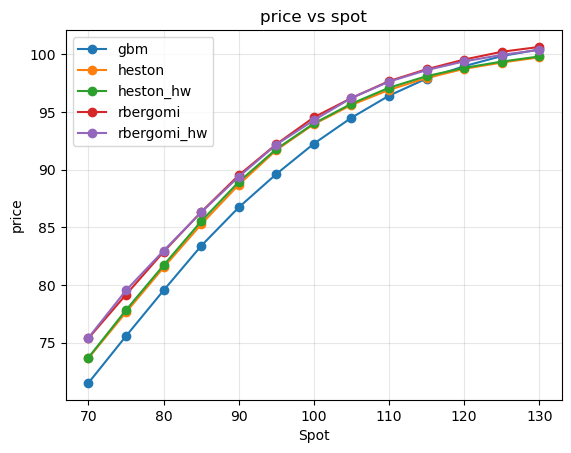

In [ ]:

spot_grid = np.linspace(0.7*S0, 1.3*S0, 13)

def sweep(metric: str, prod, model_name: str):
    vals=[]
    for s in spot_grid:
        vals.append(price_and_greeks(prod, model_name, float(s))[metric])
    return np.array(vals, dtype=float)

for metric in ["price","delta","gamma","vega","rho_DV01"]:
    plt.figure()
    for m in MODELS:
        plt.plot(spot_grid, sweep(metric, product, m), marker="o", label=m)
    plt.xlabel("Spot"); plt.ylabel(metric); plt.title(f"{metric} vs spot")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()


## Plots vs remaining maturity

In [ ]:

T_grid = [5.0,4.0,3.0,2.0,1.0,0.5]

def make_like(prod, T):
    return make_athena(T) if isinstance(prod, AutocallAthenaProduct) else make_phoenix(T)

for metric in ["price","delta","gamma","vega"]:
    plt.figure()
    for m in MODELS:
        y=[]
        for T in T_grid:
            y.append(price_and_greeks(make_like(product, T), m, S0)[metric])
        plt.plot(T_grid, y, marker="o", label=m)
    plt.gca().invert_xaxis()
    plt.xlabel("Remaining maturity (years)"); plt.ylabel(metric)
    plt.title(f"{metric} vs remaining maturity")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()


## Correlation analysis


,rho_sr,price,se
0,-0.9,92.779074,0.222260
1,-0.8,92.715924,0.223516
2,-0.7,92.678794,0.224504
3,-0.6,92.684181,0.224997
4,-0.5,92.660847,0.225695
5,-0.4,92.620334,0.226509
6,-0.3,92.572037,0.227157
7,-0.2,92.582224,0.227575
8,-0.1,92.591897,0.228076
9,0.0,92.549096,0.228708


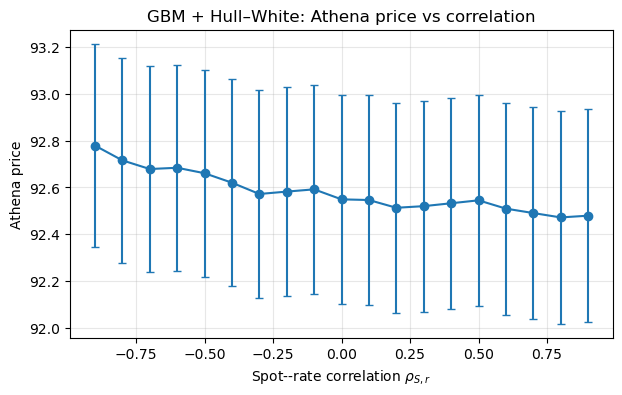

In [ ]:
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p] + list(p.parents):
        if (parent / "pyproject.toml").is_file() and (parent / "src" / "pricer").is_dir():
            return parent
    raise FileNotFoundError(
        "Could not find repo root containing pyproject.toml and src/pricer.\n"
        f"Start was: {start}\n"
        "Move the notebook inside the repo, or set ROOT_V5 manually."
    )

repo_root = find_repo_root(Path.cwd())
src_path = str(repo_root / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)


for k in list(sys.modules.keys()):
    if k == "pricer" or k.startswith("pricer."):
        del sys.modules[k]

import os, sys
from pathlib import Path

import pricer
import pricer.core.models as models_mod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pricer.core.models import Model
from pricer.core.pricing import MonteCarloPricer
from pricer.core.observation import ObservationFrequency
from pricer.core.products import AutocallAthenaProduct

product = AutocallAthenaProduct(
    nominal=100.0,
    strike=100.0,
    coupon_per_year=0.04,
    maturity_years_=5.0,
    obs_freq=ObservationFrequency.ANNUAL,
    call_barrier=1.0,
    protection_barrier=0.7,
    steps_per_year=52,
    with_memory=False,
)

pricer = MonteCarloPricer(antithetic=True, control_variate=True)

RHO_GRID = np.linspace(-0.9, 0.9, 19)
rows = []

for rho in RHO_GRID:
    model = Model(
        spot_process="GBM",
        rate_process="HULLWHITE",
        vol_process="FLAT",
        s0=100.0,
        sigma=0.20,
        r0=0.02,
        a=0.10,
        b=0.02,
        sigma_r=0.01,
        rho_sr=float(rho),
        rho_vr=0.0,
        steps_per_year=52,
        n_paths=5_000,
        seed=12345,   # CRN across rho
    )

    price, se = pricer.price(product, model)
    rows.append({"rho_sr": float(rho), "price": float(price), "se": float(se)})

df_corr = pd.DataFrame(rows)
display(df_corr)

plt.figure(figsize=(7,4))
plt.errorbar(df_corr["rho_sr"], df_corr["price"], yerr=1.96*df_corr["se"], marker="o", capsize=3)
plt.xlabel(r"Spot--rate correlation $\rho_{S,r}$")
plt.ylabel("Athena price")
plt.title("GBM + Hull–White: Athena price vs correlation")
plt.grid(True, alpha=0.3)
plt.show()


,rho_sr,athena_price,athena_se,athena_rel_pct,athena_dRel_drho_pct,phoenix_price,phoenix_se,phoenix_rel_pct,phoenix_dRel_drho_pct
0,-0.9,92.779074,0.222260,0.248492,-0.682332,95.632974,0.216684,0.294351,-0.655103
1,-0.8,92.715924,0.223516,0.180259,-0.541765,95.570508,0.218043,0.228841,-0.526763
2,-0.7,92.678794,0.224504,0.140139,-0.171493,95.532518,0.219288,0.188999,-0.206129
3,-0.6,92.684181,0.224997,0.145960,-0.096957,95.531198,0.220161,0.187615,-0.127654
4,-0.5,92.660847,0.225695,0.120748,-0.344939,95.508174,0.221032,0.163468,-0.405376
5,-0.4,92.620334,0.226509,0.076973,-0.479799,95.453891,0.222065,0.106540,-0.538428
6,-0.3,92.572037,0.227157,0.024788,-0.205889,95.405493,0.222892,0.055782,-0.275300
7,-0.2,92.582224,0.227575,0.035795,0.107296,95.401390,0.223428,0.051480,-0.018323
8,-0.1,92.591897,0.228076,0.046247,-0.178973,95.401999,0.224031,0.052118,-0.257399
9,0.0,92.549096,0.228708,0.000000,-0.246584,95.352303,0.224676,0.000000,-0.308245


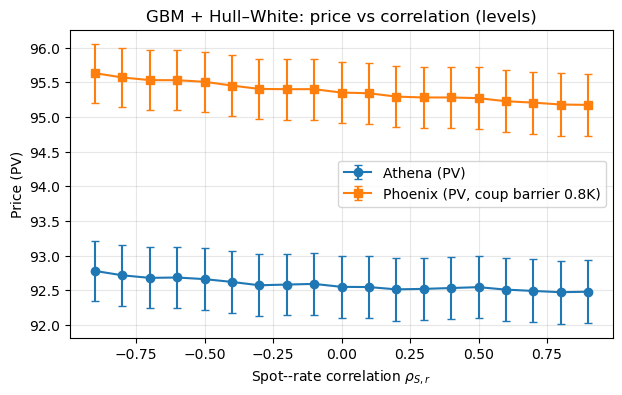

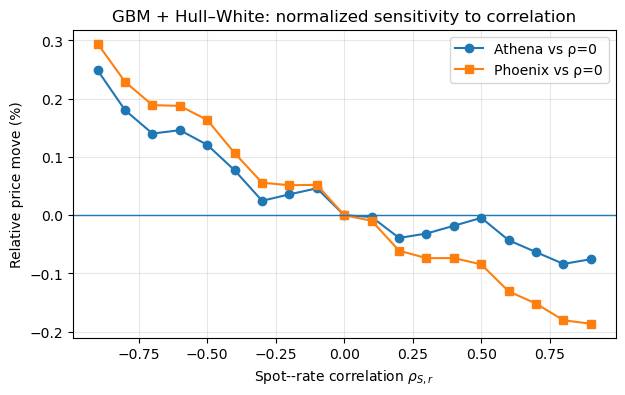

In [ ]:
#import os, sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p] + list(p.parents):
        if (parent / "pyproject.toml").is_file() and (parent / "src" / "pricer").is_dir():
            return parent
    raise FileNotFoundError(
        "Could not find repo root containing pyproject.toml and src/pricer.\n"
        f"Start was: {start}\n"
        "Move the notebook inside the repo, or set ROOT_V5 manually."
    )

repo_root = find_repo_root(Path.cwd())
src_path = str(repo_root / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)


for k in list(sys.modules.keys()):
    if k == "pricer" or k.startswith("pricer."):
        del sys.modules[k]

import pricer
import pricer.core.models as models_mod




idx0 = (df_corr["rho_sr"].abs()).idxmin()
rho0 = float(df_corr.loc[idx0, "rho_sr"])

P0_a = float(df_corr.loc[idx0, "athena_price"])
P0_p = float(df_corr.loc[idx0, "phoenix_price"])


df_corr["athena_rel_pct"]  = 100.0 * (df_corr["athena_price"] / P0_a - 1.0)
df_corr["phoenix_rel_pct"] = 100.0 * (df_corr["phoenix_price"] / P0_p - 1.0)


df_corr["athena_dP_drho"]  = np.gradient(df_corr["athena_price"].values,  df_corr["rho_sr"].values)
df_corr["phoenix_dP_drho"] = np.gradient(df_corr["phoenix_price"].values, df_corr["rho_sr"].values)


df_corr["athena_dRel_drho_pct"]  = 100.0 * df_corr["athena_dP_drho"] / P0_a
df_corr["phoenix_dRel_drho_pct"] = 100.0 * df_corr["phoenix_dP_drho"] / P0_p

display(df_corr[[
    "rho_sr",
    "athena_price", "athena_se", "athena_rel_pct", "athena_dRel_drho_pct",
    "phoenix_price","phoenix_se","phoenix_rel_pct","phoenix_dRel_drho_pct",
]])


plt.figure(figsize=(7,4))
plt.errorbar(df_corr["rho_sr"], df_corr["athena_price"], yerr=1.96*df_corr["athena_se"],
             marker="o", capsize=3, label="Athena (PV)")
plt.errorbar(df_corr["rho_sr"], df_corr["phoenix_price"], yerr=1.96*df_corr["phoenix_se"],
             marker="s", capsize=3, label="Phoenix (PV, coup barrier 0.8K)")
plt.xlabel(r"Spot--rate correlation $\rho_{S,r}$")
plt.ylabel("Price (PV)")
plt.title("GBM + Hull–White: price vs correlation (levels)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(7,4))
plt.plot(df_corr["rho_sr"], df_corr["athena_rel_pct"], marker="o", label=f"Athena vs ρ={rho0:g}")
plt.plot(df_corr["rho_sr"], df_corr["phoenix_rel_pct"], marker="s", label=f"Phoenix vs ρ={rho0:g}")
plt.axhline(0.0, linewidth=1)
plt.xlabel(r"Spot--rate correlation $\rho_{S,r}$")
plt.ylabel("Relative price move (%)")
plt.title("GBM + Hull–White: normalized sensitivity to correlation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
